Here, we visualize the bias components being generated during the forward pass for prediction. We are looking at how the various components of bias separate by categories of interest.

While this is quite similar to notebook 06Eiii conceptually (isolating the bias components and seeing how they separate by categorical covariate), it is using the data generated for [Notebook 06D](../06D_AdverserialBias.ipynb) (looking at the generated bias, in that notebook, to ensure that the adverserial training was working so we focused only on cell type and not stimulation information). 

 These are only predictions, so we cannot compare them to actual data as in the other 06E notebooks) but we can see if they separate by stimulation condition. Biases were calculated in [Notebook 06D](./06D_AdverserialBias.ipynb).

Our expectation is that the total bias separates by cell type (shown in Notebook 06D), BUT NOT stimulation type (explored here)

In [2]:
import os

from tqdm import tqdm

import pandas as pd
import scanpy as sc
import numpy as np

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../../.')
from Kang_utils import adata_dimviz_bias 


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [6]:
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
# from scLEMBAS.preprocess import embed_tf_activity

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

author = 'Kang'

In [4]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

# 0. Parameters

In [9]:
calculation_type = 'project' # project data rather than embed
n_neighbors = 15 # clustering as before
run_umap = True # also get the prediction umaps in addition to pca
best_resolution = tf_adata.uns['leiden']['params']['resolution']

Load the biases generated in [Notebook 06D](./06D_AdverserialBias.ipynb)

In [7]:
biases_clustered = io.read_pickled_object(os.path.join(data_path, 'interim', author + '_clustered_biases.pickle'))

cat_map = {'seurat_annotations': 'Cell Type', 
          'stim': 'Stimulation'}

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.1 Opposite Counterfactual

In [8]:
counterfactual_type = 'opposite'

In [9]:
subset_size = None if counterfactual_type == 'opposite' else 3000

_, bias_global, bias_tot, bias_cats = biases_clustered[counterfactual_type]
bias_types = {'Global': bias_global, 
             'Categorical': bias_cats, 
             'Total': bias_tot}

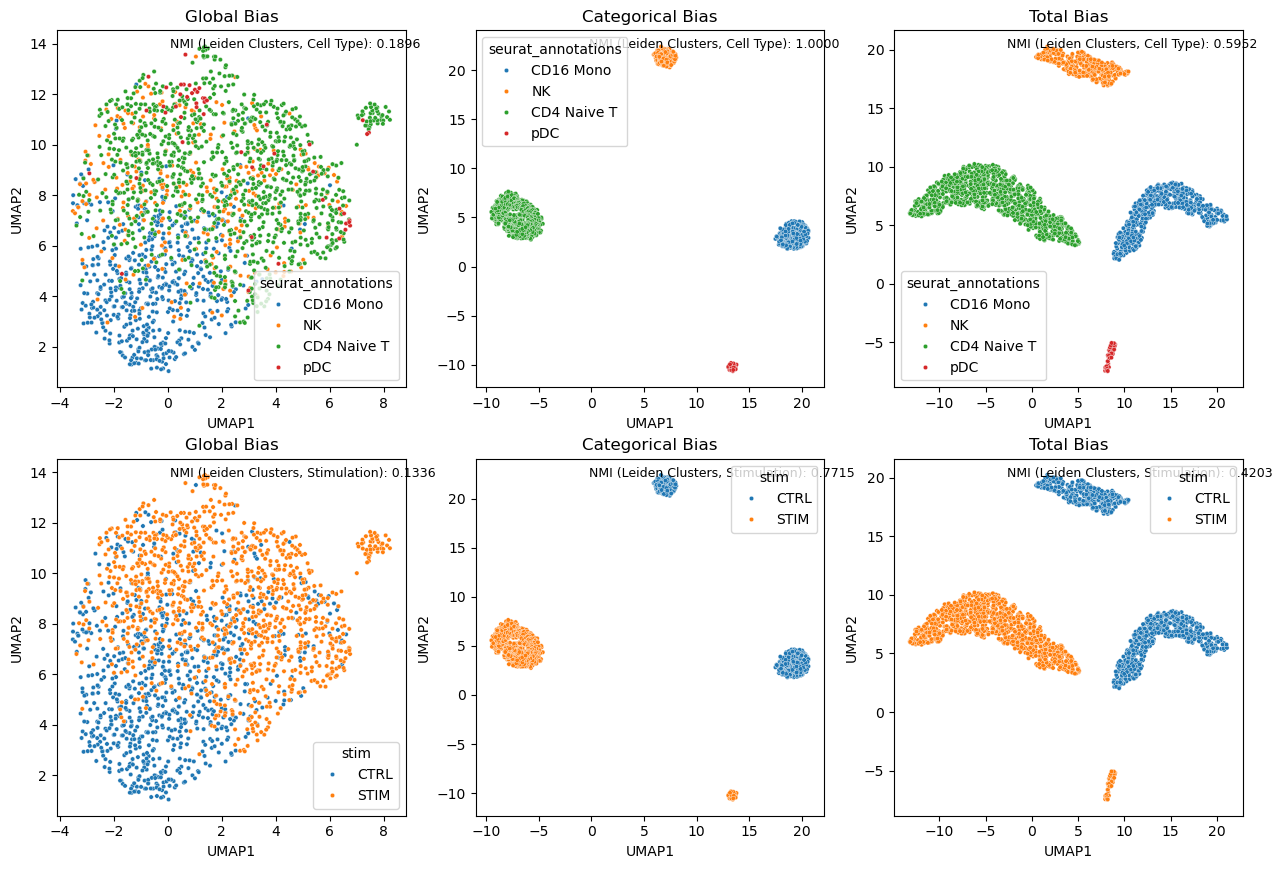

In [10]:
ncols = len(bias_types)
nrows = len(cat_map)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(['seurat_annotations', 'stim']):
        viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                        reduction_type = 'umap', 
                                        cat = cat,
                                        subset_size = subset_size)


        sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = cat, 
                        s=10,
                        ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')

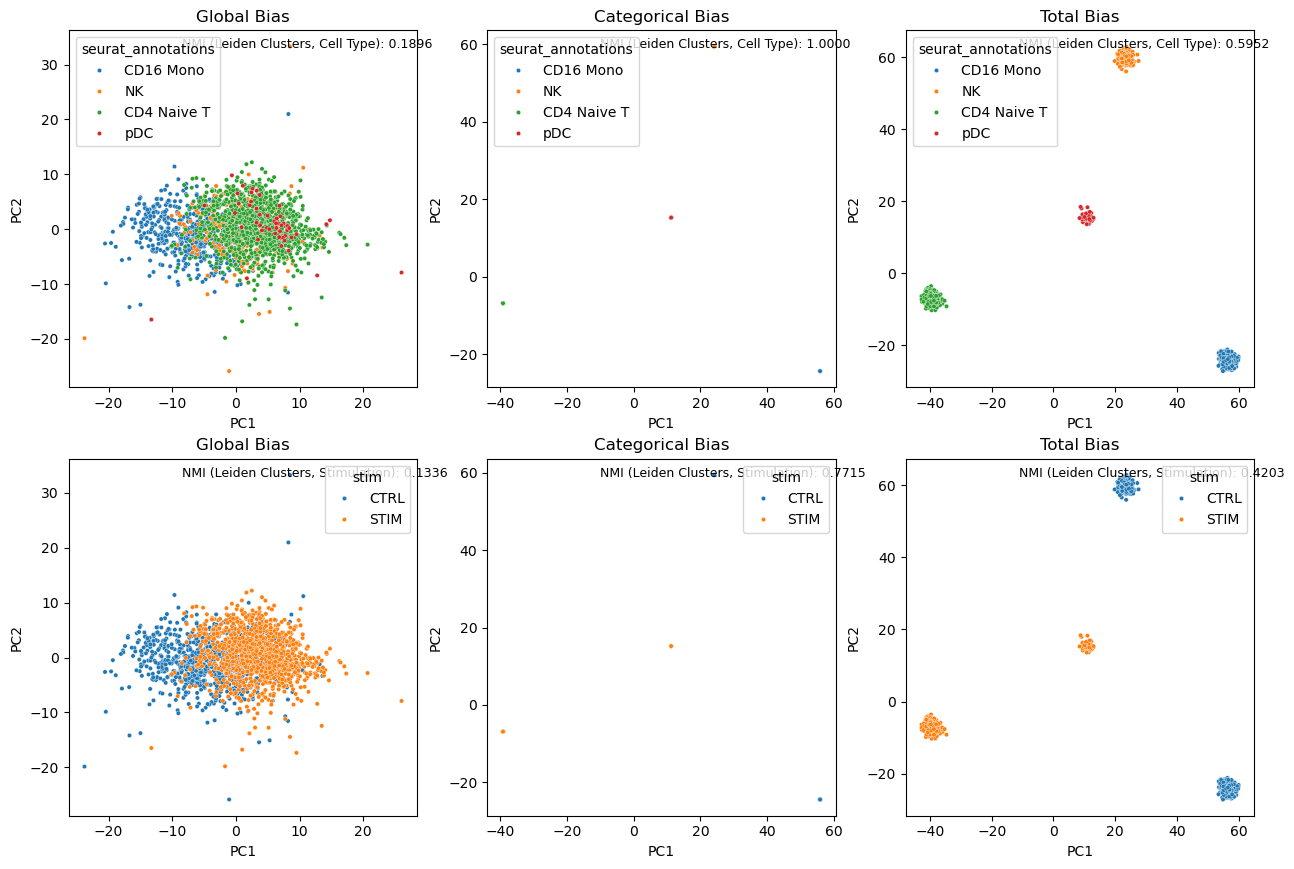

In [11]:
ncols = len(bias_types)
nrows = len(cat_map)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(['seurat_annotations', 'stim']):
        viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                        reduction_type = 'pca', 
                                        cat = cat,
                                        subset_size = subset_size)


        sns.scatterplot(data = viz_df, x = 'PCA1', y = 'PCA2', hue = cat, 
                        s=10,
                        ax = ax[i,j])
        
        ax[i,j].set_xlabel('PC1')
        ax[i,j].set_ylabel('PC2')
        
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')

For categorical and total bias, it's not really possible to tell whether stimulation is driving separation since each cell type is just one stimulation condition. However, for global bias, we can see a trend of separation due to stimulation. This is not suprrising since the gene expression vector does contain stimulation information, but it's also not ideal. It is still difficult to tell because the cell type information not being fully removed can be driving it as well. 

## 2.2 In Distribution Counterfactual

In [12]:
counterfactual_type = 'in_distribution'

In [13]:
subset_size = None if counterfactual_type == 'opposite' else 3000

_, bias_global, bias_tot, bias_cats = biases_clustered[counterfactual_type]
bias_types = {'Global': bias_global, 
             'Categorical': bias_cats, 
             'Total': bias_tot}

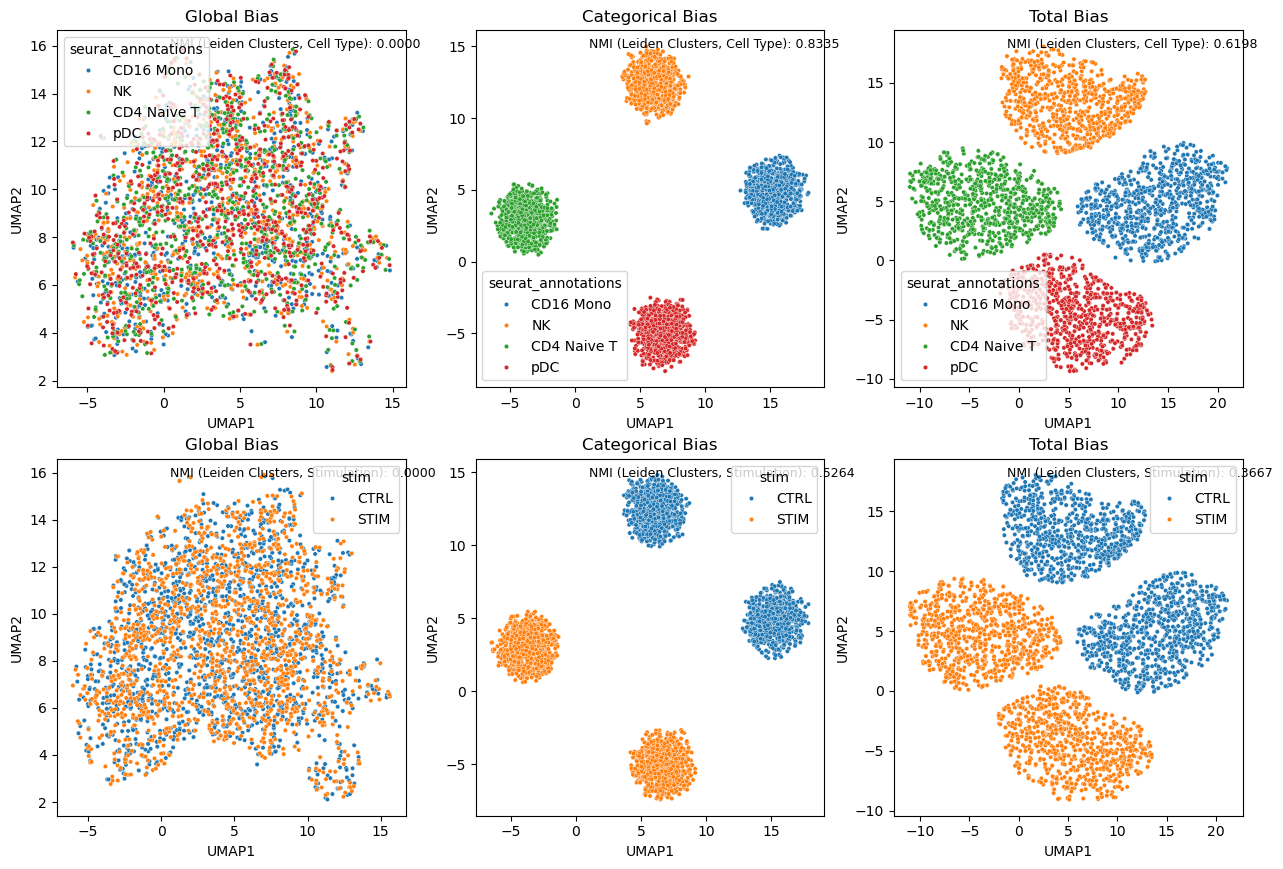

In [14]:
ncols = len(bias_types)
nrows = len(cat_map)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(['seurat_annotations', 'stim']):
        viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                        reduction_type = 'umap', 
                                        cat = cat,
                                        subset_size = subset_size, 
                                       seed = seed)


        sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = cat, 
                        s=10,
                        ax = ax[i,j])
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')

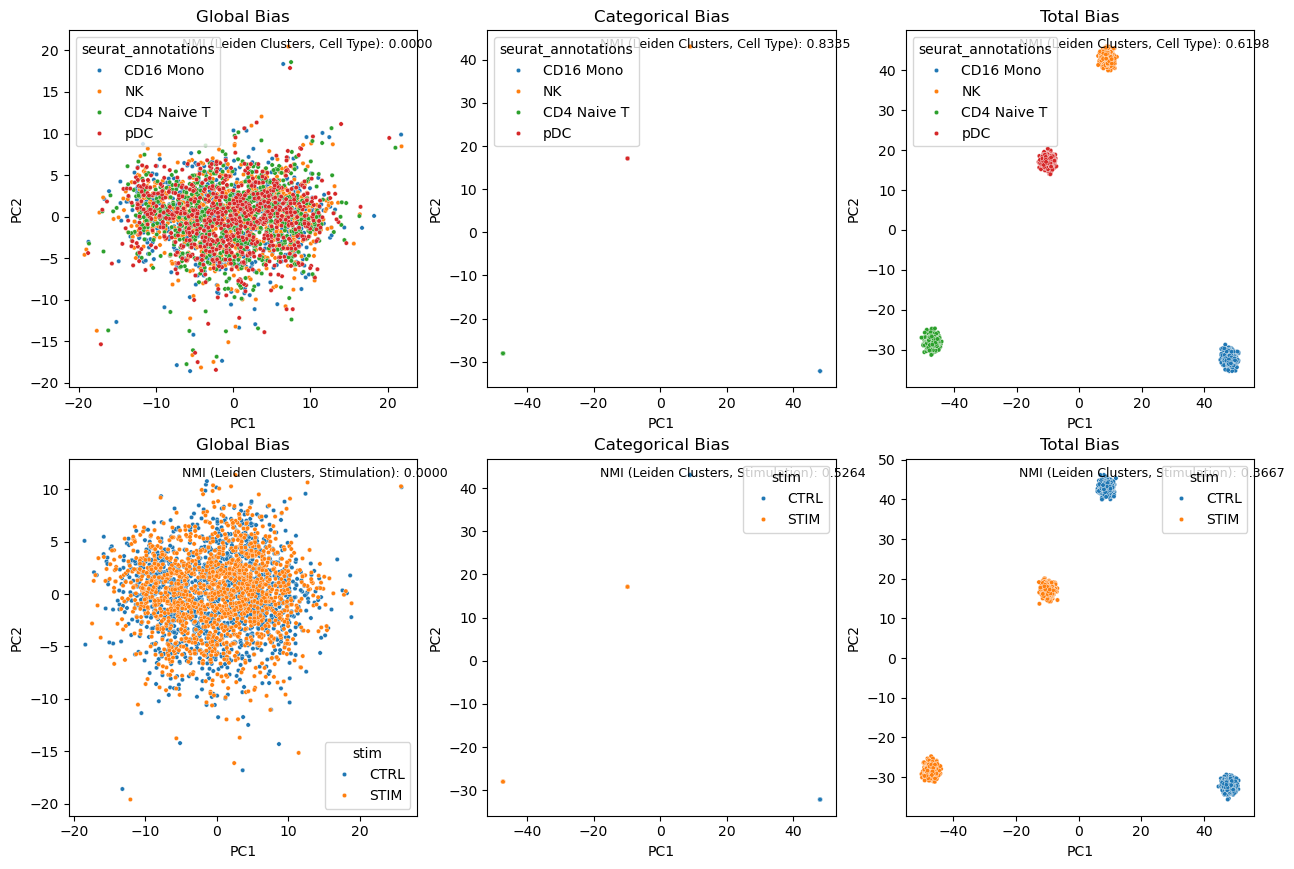

In [15]:
ncols = len(bias_types)
nrows = len(cat_map)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols *5.1, nrows*5.1))

for j, (bias_type, bias) in enumerate(bias_types.items()):
    for i, cat in enumerate(['seurat_annotations', 'stim']):
        viz_df, nmi = adata_dimviz_bias(adata = bias, 
                                        reduction_type = 'pca', 
                                        cat = cat,
                                        subset_size = subset_size)


        sns.scatterplot(data = viz_df, x = 'PCA1', y = 'PCA2', hue = cat, 
                        s=10,
                        ax = ax[i,j])
        
        ax[i,j].set_xlabel('PC1')
        ax[i,j].set_ylabel('PC2')
        
        ax[i,j].annotate('NMI (Leiden Clusters, ' + cat_map[cat] + '): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i,j].set_title(bias_type + ' Bias')